<a href="https://colab.research.google.com/github/liorock1/Partial-SAM-COMP5329/blob/main/PartialSam_structucal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Structural Ablation — Partial-SAM
**COMP5329**

This notebook runs the **Structural Ablation** experiments for our Partial-SAM paper.

| Fixed | Varied |
|-------|--------|
| `alpha = 1.0` (SAM every epoch) | Which ResNet-18 blocks receive perturbation |
| `rho = 0.05`, `epochs = 200` | `first1 / first2 / last1 / last2 / all4` |

**Run order:**
1. `Section 1–5` — setup (run once)
2. `Section 6` — run one config at a time (or loop all)
3. `Section 7` — generate Table 2 + Figure 2 after all runs finish


## Section 1 · Environment Setup

In [ ]:
# Check GPU — you should see a CUDA device, not CPU
import torch
print("PyTorch version:", torch.__version__)
print("Device:", "GPU " if torch.cuda.is_available() else "CPU")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
Device: GPU 
GPU: Tesla T4


## Section 2 · Imports

In [ ]:
import os, csv, time, copy
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

## Section 3 · Optimizers

Two classes:
- **`SAM`** — full Sharpness-Aware Minimization (Foret et al. 2021). Used when `layers = all4`.
- **`PartialSAM`** — perturbs only the selected layers during the ascent step; SGD update still covers all params.


In [ ]:
class SAM(optim.Optimizer):
    """Full SAM — perturbs all parameters. Used for the all4 baseline."""
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        assert rho >= 0.0
        defaults = dict(rho=rho, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                e_w = p.grad * scale.to(p)
                p.add_(e_w)
                self.state[p]["e_w"] = e_w
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.sub_(self.state[p]["e_w"])
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def _grad_norm(self):
        dev = self.param_groups[0]["params"][0].device
        return torch.norm(torch.stack([
            p.grad.norm(p=2).to(dev)
            for group in self.param_groups
            for p in group["params"] if p.grad is not None
        ]), p=2)

    def load_state_dict(self, state_dict):
        super().load_state_dict(state_dict)
        self.base_optimizer.param_groups = self.param_groups


class PartialSAM:
    """
    Structural Partial-SAM.
    Ascent step perturbs only `sam_params` (selected layers).
    Descent step (SGD) updates ALL parameters.
    """
    def __init__(self, all_params, sam_params, base_optimizer_cls, rho=0.05, **kwargs):
        self.base_optimizer = base_optimizer_cls(all_params, **kwargs)
        self.sam_params = list(sam_params)
        self.rho = rho

    def zero_grad(self): self.base_optimizer.zero_grad()

    @torch.no_grad()
    def first_step(self):
        grads = [p.grad for p in self.sam_params if p.grad is not None]
        if not grads: return
        grad_norm = torch.norm(torch.stack([g.norm(p=2) for g in grads]), p=2)
        scale = self.rho / (grad_norm + 1e-12)
        for p in self.sam_params:
            if p.grad is None: continue
            e_w = p.grad * scale
            p.add_(e_w)
            p._e_w = e_w

    @torch.no_grad()
    def second_step(self):
        for p in self.sam_params:
            if hasattr(p, '_e_w'): p.sub_(p._e_w)
        self.base_optimizer.step()

    def state_dict(self):   return self.base_optimizer.state_dict()
    def load_state_dict(self, d): self.base_optimizer.load_state_dict(d)

print("Optimizers defined ")

Optimizers defined 


## Section 4 · Model & Layer Selector

`get_layer_params` is the core of the structural ablation.
It maps a config name to the **exact PyTorch parameter tensors** that will be perturbed.

| Config | Blocks perturbed | ~Params | Hypothesis role |
|--------|-----------------|---------|-----------------|
| `first1` | B1 | 148 K | Shallow control |
| `first2` | B1 + B2 | 674 K | Shallow control |
| `last1` | B4 | 8.4 M | Minimal deep |
| `last2` | B3 + B4 | 10.5 M | **Our hypothesis** |
| `all4` | all blocks | 11.2 M | Full SAM baseline |


In [ ]:
def build_resnet18_cifar(num_classes=100):
    """ResNet-18 with 3×3 stem and no maxpool — standard CIFAR-100 setup."""
    model = models.resnet18(weights=None, num_classes=num_classes)
    model.conv1  = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model


def get_layer_params(model, layers_config):
    """Return parameters that receive SAM perturbation for a given config."""
    layer_map = {
        'first1': [model.layer1],
        'first2': [model.layer1, model.layer2],
        'last1':  [model.layer4],
        'last2':  [model.layer3, model.layer4],
        'all4':   [model.layer1, model.layer2, model.layer3, model.layer4],
    }
    return [p for block in layer_map[layers_config] for p in block.parameters()]


def count_perturbed_params(model, layers_config):
    """Report how many params are perturbed — goes into Table 2 footnote."""
    n_pert  = sum(p.numel() for p in get_layer_params(model, layers_config))
    n_total = sum(p.numel() for p in model.parameters())
    return n_pert, n_total


# Quick sanity check — print param distribution
_m = build_resnet18_cifar()
print(f"{'Config':<10} {'Perturbed':>12} {'Total':>10} {'%':>7}")
print("-" * 45)
for cfg in ['first1', 'first2', 'last1', 'last2', 'all4']:
    n, t = count_perturbed_params(_m, cfg)
    print(f"{cfg:<10} {n:>12,} {t:>10,} {100*n/t:>6.1f}%")
del _m

Config        Perturbed      Total       %
---------------------------------------------
first1          147,968 11,220,132    1.3%
first2          673,536 11,220,132    6.0%
last1         8,393,728 11,220,132   74.8%
last2        10,493,440 11,220,132   93.5%
all4         11,166,976 11,220,132   99.5%


## Section 5 · Data Loading & Sharpness Measurement

In [ ]:
def get_dataloaders(batch_size=256, num_workers=2):
    mean = (0.5071, 0.4865, 0.4409)
    std  = (0.2673, 0.2564, 0.2761)
    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    train_set = torchvision.datasets.CIFAR100('./data', train=True,  download=True, transform=train_tf)
    test_set  = torchvision.datasets.CIFAR100('./data', train=False, download=True, transform=test_tf)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True,
                                               num_workers=num_workers, pin_memory=True)
    test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=256, shuffle=False,
                                               num_workers=num_workers, pin_memory=True)
    return train_loader, test_loader

def measure_sharpness(model, loader, criterion, device, rho=0.05, n_batches=5):
    model.eval()
    base_l, pert_l = [], []
    for i, (x, y) in enumerate(loader):
        if i >= n_batches: break
        x, y = x.to(device), y.to(device)
        model.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        base_l.append(loss.item())
        loss.backward()
        saved = {n: p.data.clone()
                 for n, p in model.named_parameters() if p.grad is not None}
        gn = torch.norm(torch.stack([
            p.grad.norm() for p in model.parameters() if p.grad is not None
        ]))
        scale = rho / (gn + 1e-12)
        for p in model.parameters():
            if p.grad is not None:
                p.data.add_(p.grad * scale)
        with torch.no_grad():
            pert_l.append(criterion(model(x), y).item())
        for n, p in model.named_parameters():
            if n in saved:
                p.data.copy_(saved[n])
        model.zero_grad()
    return max(0.0, sum(pert_l)/len(pert_l) - sum(base_l)/len(base_l))

print("Data & sharpness functions defined")

Data & sharpness functions defined


## Section 6 · Training Loops

In [ ]:
def train_epoch_sgd(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x); loss = criterion(out, y)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct    += out.argmax(1).eq(y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total


def train_epoch_sam(model, loader, optimizer, criterion, device, is_partial=False):
    """Two-pass SAM update. Pass 1: ascent (compute ε̂). Pass 2: descent from w+ε̂."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        # Pass 1 — ascent
        optimizer.zero_grad()
        out = model(x); loss = criterion(out, y); loss.backward()
        if is_partial:
            optimizer.first_step(); optimizer.zero_grad()
        else:
            optimizer.first_step(zero_grad=True)
        # Pass 2 — descent
        out2 = model(x); loss2 = criterion(out2, y); loss2.backward()
        optimizer.second_step() if is_partial else optimizer.second_step(zero_grad=True)
        total_loss += loss2.item() * y.size(0)
        correct    += out2.argmax(1).eq(y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x); loss = criterion(out, y)
        total_loss += loss.item() * y.size(0)
        correct    += out.argmax(1).eq(y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total

print("Training loops defined ")

Training loops defined 


## Section 7 · Main Training Function

In [ ]:
def train_structural(layers_config, seed, epochs=200, rho=0.05,
                     outdir='results', sgd_only=False):
    """
    One full training run for the structural ablation.
    Results are appended to results/results_structural.csv after each run.
    """
    torch.manual_seed(seed); torch.cuda.manual_seed(seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    label = 'SGD-baseline' if sgd_only else f'StructSAM-{layers_config}'
    print(f"\n{'='*55}")
    print(f"Run : {label}  |  seed={seed}  |  device={device}")
    print(f"{'='*55}")

    train_loader, test_loader = get_dataloaders()
    model     = build_resnet18_cifar().to(device)
    criterion = nn.CrossEntropyLoss()

    if not sgd_only:
        n_pert, n_total = count_perturbed_params(model, layers_config)
        print(f"Perturbed params : {n_pert:,} / {n_total:,} ({100*n_pert/n_total:.1f}%)")

    sgd_kwargs = dict(lr=0.1, momentum=0.9, weight_decay=5e-4)

    if sgd_only:
        optimizer  = optim.SGD(model.parameters(), **sgd_kwargs)
        is_partial = False; use_sam = False
    elif layers_config == 'all4':
        optimizer  = SAM(model.parameters(), optim.SGD, rho=rho, **sgd_kwargs)
        is_partial = False; use_sam = True
    else:
        sam_params = get_layer_params(model, layers_config)
        optimizer  = PartialSAM(list(model.parameters()), sam_params,
                                optim.SGD, rho=rho, **sgd_kwargs)
        is_partial = True; use_sam = True

    inner_sgd = optimizer if sgd_only else optimizer.base_optimizer
    scheduler = optim.lr_scheduler.CosineAnnealingLR(inner_sgd, T_max=epochs)

    history = []; best_acc = 0.0; best_state = None

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        if use_sam:
            tr_loss, tr_acc = train_epoch_sam(model, train_loader, optimizer,
                                              criterion, device, is_partial)
        else:
            tr_loss, tr_acc = train_epoch_sgd(model, train_loader, optimizer,
                                              criterion, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)
        scheduler.step()

        history.append({'epoch': epoch,
                        'train_acc': round(tr_acc*100, 2),
                        'test_acc':  round(te_acc*100, 2)})
        if te_acc > best_acc:
            best_acc = te_acc
            best_state = copy.deepcopy(model.state_dict())
        if epoch % 20 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs}  "
                  f"train {tr_acc*100:.1f}%  test {te_acc*100:.1f}%  "
                  f"({time.time()-t0:.0f}s)")

    # ── Final metrics ──────────────────────────────────────────────
    model.load_state_dict(best_state)
    _, final_acc = evaluate(model, test_loader, criterion, device)
    print("\nMeasuring sharpness...")
    sharpness = measure_sharpness(model, train_loader, criterion, device,
                                  rho=rho, n_batches=20)

    if sgd_only:
        flops_saved = 50.0
    else:
        n_pert, n_total = count_perturbed_params(model, layers_config)
        flops_saved = round((1 - n_pert/n_total) / 2 * 100, 1)

    print(f"\n  Final accuracy : {final_acc*100:.2f}%")
    print(f"  ρ-Sharpness    : {sharpness:.4f}")
    print(f"  FLOPs saved    : {flops_saved}%")

    # ── Save results ───────────────────────────────────────────────
    os.makedirs(outdir, exist_ok=True)
    row = {
        'layers':      'SGD' if sgd_only else layers_config,
        'seed':        seed,
        'test_acc':    round(final_acc*100, 2),
        'sharpness':   round(sharpness, 4),
        'flops_saved': flops_saved,
    }
    csv_path = os.path.join(outdir, 'results_structural.csv')
    file_exists = os.path.isfile(csv_path)
    with open(csv_path, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=row.keys())
        if not file_exists: w.writeheader()
        w.writerow(row)

    # Per-epoch history
    lbl = 'sgd' if sgd_only else layers_config
    hist_path = os.path.join(outdir, f'history_{lbl}_s{seed}.csv')
    with open(hist_path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=history[0].keys())
        w.writeheader(); w.writerows(history)

    # Checkpoint
    torch.save({'model': best_state, 'config': row},
               os.path.join(outdir, f'ckpt_{lbl}_s{seed}.pth'))
    print(f"  Saved → {csv_path}")
    return row

print("train_structural() defined ")

train_structural() defined 


## Section 8 · Run Experiments

In [ ]:
import os, pandas as pd

OUTDIR = 'results'

ALL_CONFIGS = [
    ('first1', 42),
    ('first2', 42),
    ('last1',  42),
    ('last2',  42),
    ('all4',   42),
]
SGD_SEEDS = [42]

# Auto-skip completed runs
csv_path = os.path.join(OUTDIR, 'results_structural.csv')
done = set()
if os.path.exists(csv_path):
    df_done = pd.read_csv(csv_path)
    for _, r in df_done.iterrows():
        done.add((str(r['layers']), int(r['seed'])))
    print(f"Already completed {len(done)} runs, skipping:")
    for d in done:
        print(f"   {d[0]} seed={d[1]}")

print(f"\n{6 - len(done)} runs remaining\n")

# SAM runs (5 total)
for layers, seed in ALL_CONFIGS:
    if (layers, seed) in done:
        continue
    train_structural(layers, seed, epochs=20, outdir=OUTDIR)

# SGD baseline (1 total)
for seed in SGD_SEEDS:
    if ('SGD', seed) in done:
        continue
    train_structural('all4', seed, epochs=20, outdir=OUTDIR, sgd_only=True)

print("\n All 6 runs complete!")


6 runs remaining


Run : StructSAM-first1  |  seed=42  |  device=cuda


100%|██████████| 169M/169M [00:14<00:00, 11.8MB/s]


Perturbed params : 147,968 / 11,220,132 (1.3%)
  Epoch   1/20  train 9.5%  test 15.7%  (82s)
  Epoch  20/20  train 91.5%  test 71.7%  (83s)

Measuring sharpness...

  Final accuracy : 71.65%
  ρ-Sharpness    : 0.1845
  FLOPs saved    : 49.3%
  Saved → results/results_structural.csv

Run : StructSAM-first2  |  seed=42  |  device=cuda
Perturbed params : 673,536 / 11,220,132 (6.0%)
  Epoch   1/20  train 9.8%  test 15.1%  (84s)
  Epoch  20/20  train 91.0%  test 71.0%  (83s)

Measuring sharpness...

  Final accuracy : 71.04%
  ρ-Sharpness    : 0.1784
  FLOPs saved    : 47.0%
  Saved → results/results_structural.csv

Run : StructSAM-last1  |  seed=42  |  device=cuda
Perturbed params : 8,393,728 / 11,220,132 (74.8%)
  Epoch   1/20  train 8.8%  test 13.7%  (83s)
  Epoch  20/20  train 87.4%  test 71.1%  (84s)

Measuring sharpness...

  Final accuracy : 71.55%
  ρ-Sharpness    : 0.2043
  FLOPs saved    : 12.6%
  Saved → results/results_structural.csv

Run : StructSAM-last2  |  seed=42  |  device

## Section 9 · Generate Table 2 + Figure 2

Run this cell **after all experiments are finished**.


TABLE 2: Structural Ablation (ResNet-18, CIFAR-100, 20 epochs)
Config                       Acc (%)    Sharpness   FLOPs saved
-----------------------------------------------------------------
SGD (no SAM)            72.19 ± 0.00     0.1914        50.0%
First-1 (B1)            71.65 ± 0.00     0.1845        49.3%
First-2 (B1+B2)         71.04 ± 0.00     0.1784        47.0%
Last-1 (B4)             71.55 ± 0.00     0.2043        12.6%
Last-2 (B3+B4)          71.59 ± 0.00     0.1887         3.2%
All-4 (Full SAM)        71.75 ± 0.00     0.1749         0.2%

  Best config : SGD  (72.19%, 50.0% FLOPs saved)

Figure saved → results/structural_barplot.png


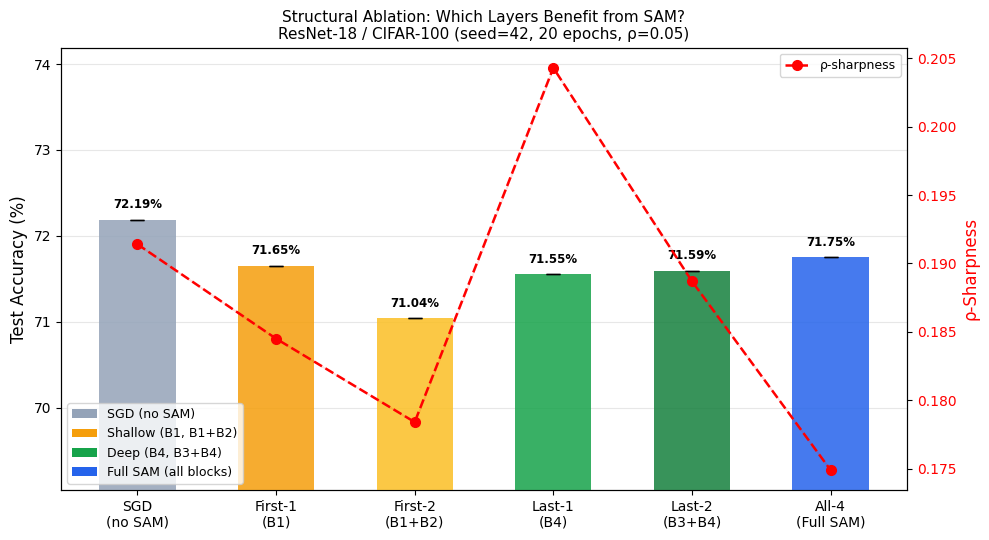

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

df = pd.read_csv('results/results_structural.csv')

ORDER  = ['SGD', 'first1', 'first2', 'last1', 'last2', 'all4']
LABELS = {
    'SGD':    'SGD\n(no SAM)',
    'first1': 'First-1\n(B1)',
    'first2': 'First-2\n(B1+B2)',
    'last1':  'Last-1\n(B4)',
    'last2':  'Last-2\n(B3+B4)',
    'all4':   'All-4\n(Full SAM)',
}

agg = (df.groupby('layers')
         .agg(acc_mean   =('test_acc',  'mean'),
              acc_std    =('test_acc',  'std'),
              sharp_mean =('sharpness', 'mean'),
              sharp_std  =('sharpness', 'std'),
              flops_saved=('flops_saved','first'))
         .reindex([o for o in ORDER if o in df['layers'].values])
         .reset_index())

# 修复NaN（单seed时std为NaN）
agg['acc_std']   = agg['acc_std'].fillna(0)
agg['sharp_std'] = agg['sharp_std'].fillna(0)

# ── Table 2 ───────────────────────────────────────────────────────
print("=" * 65)
print("TABLE 2: Structural Ablation (ResNet-18, CIFAR-100, 20 epochs)")
print("=" * 65)
print(f"{'Config':<22} {'Acc (%)':>13}  {'Sharpness':>11}  {'FLOPs saved':>12}")
print("-" * 65)
for _, r in agg.iterrows():
    lbl = LABELS.get(r['layers'], r['layers']).replace('\n', ' ')
    print(f"{lbl:<22} {r['acc_mean']:>6.2f} ± {r['acc_std']:>4.2f}  "
          f"{r['sharp_mean']:>9.4f}  {r['flops_saved']:>10.1f}%")
best = agg.loc[agg['acc_mean'].idxmax()]
print(f"\n  Best config : {best['layers']}  "
      f"({best['acc_mean']:.2f}%, {best['flops_saved']:.1f}% FLOPs saved)")

# ── Figure 2 ──────────────────────────────────────────────────────
COLORS = {'SGD':'#94a3b8','first1':'#F59E0B','first2':'#FBBF24',
          'last1':'#16A34A','last2':'#15803D','all4':'#2563EB'}

x   = np.arange(len(agg))
fig, ax1 = plt.subplots(figsize=(10, 5.5))

bars = ax1.bar(x, agg['acc_mean'], width=0.55,
               color=[COLORS.get(l,'#888') for l in agg['layers']],
               alpha=0.85, yerr=agg['acc_std'], capsize=5,
               error_kw=dict(elinewidth=1.5, ecolor='black'), zorder=3)

for bar, m in zip(bars, agg['acc_mean']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f"{m:.2f}%", ha='center', va='bottom',
             fontsize=8.5, fontweight='bold')

ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_ylim(agg['acc_mean'].min()-2, agg['acc_mean'].max()+2)
ax1.set_xticks(x)
ax1.set_xticklabels([LABELS.get(l,l) for l in agg['layers']], fontsize=10)
ax1.set_title('Structural Ablation: Which Layers Benefit from SAM?\n'
              'ResNet-18 / CIFAR-100 (seed=42, 20 epochs, ρ=0.05)', fontsize=11)
ax1.grid(axis='y', alpha=0.3, zorder=0)

ax2 = ax1.twinx()
ax2.plot(x, agg['sharp_mean'], 'r--o', linewidth=1.8,
         markersize=7, label='ρ-sharpness', zorder=5)
ax2.fill_between(x,
                 agg['sharp_mean']-agg['sharp_std'],
                 agg['sharp_mean']+agg['sharp_std'],
                 alpha=0.12, color='red')
ax2.set_ylabel('ρ-Sharpness', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right', fontsize=9)

legend_els = [
    mpatches.Patch(facecolor='#94a3b8', label='SGD (no SAM)'),
    mpatches.Patch(facecolor='#F59E0B', label='Shallow (B1, B1+B2)'),
    mpatches.Patch(facecolor='#16A34A', label='Deep (B4, B3+B4)'),
    mpatches.Patch(facecolor='#2563EB', label='Full SAM (all blocks)'),
]
ax1.legend(handles=legend_els, fontsize=9, loc='lower left')
plt.tight_layout()

os.makedirs('results', exist_ok=True)
plt.savefig('results/structural_barplot.png', dpi=150, bbox_inches='tight')
print("\nFigure saved → results/structural_barplot.png")
plt.show()

In [ ]:
from google.colab import files
files.download('results/structural_barplot.png')
files.download('results/results_structural.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>